# Attention-Augmented LSTM for Document Classification

This notebook implements an LSTM model with a Bahdanau-style additive attention mechanism for multi-class document classification using the **AG News** dataset.

## Architecture Overview
```
Input Tokens
     ↓
Embedding Layer
     ↓
Bidirectional LSTM
     ↓
Attention Layer  ← learns which words matter most
     ↓
Context Vector
     ↓
Fully Connected → Softmax → Class Label
```

## 1. Install & Import Dependencies

In [1]:
# Install required packages (run once)
# !pip install torch torchtext datasets scikit-learn matplotlib seaborn

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from datasets import load_dataset
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix

import re
import random
import time

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 2. Load & Explore the Dataset

**AG News** has 4 classes: World (0), Sports (1), Business (2), Sci/Tech (3)  
- 120,000 training samples, 7,600 test samples

In [3]:
dataset = load_dataset('ag_news')
train_data = dataset['train']
test_data  = dataset['test']

print(f"Training samples : {len(train_data):,}")
print(f"Test samples     : {len(test_data):,}")
print(f"Classes          : {train_data.features['label'].names}")

# Show a few examples
label_names = train_data.features['label'].names
for i in range(3):
    print(f"\n[{label_names[train_data[i]['label']]}] {train_data[i]['text'][:120]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training samples : 120,000
Test samples     : 7,600
Classes          : ['World', 'Sports', 'Business', 'Sci/Tech']

[Business] Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics,...

[Business] Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputat...

[Business] Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the ou...


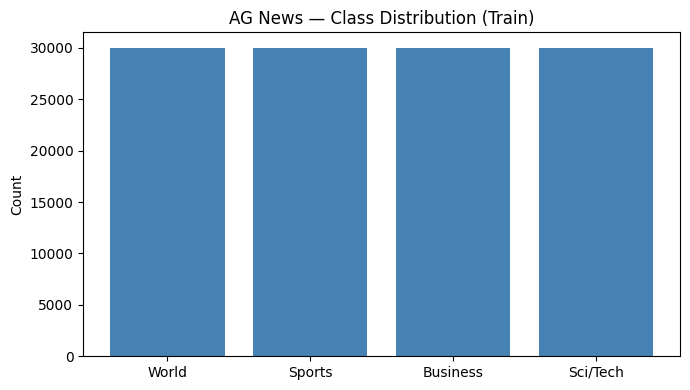

In [4]:
# Class distribution
from collections import Counter

train_labels = [x['label'] for x in train_data]
counts = Counter(train_labels)

plt.figure(figsize=(7, 4))
plt.bar([label_names[k] for k in sorted(counts)], [counts[k] for k in sorted(counts)], color='steelblue')
plt.title('AG News — Class Distribution (Train)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 3. Text Preprocessing & Vocabulary

In [5]:
# ── Hyperparameters ────────────────────────────────────────────────────────────
MAX_VOCAB    = 30_000   # keep top-N words
MAX_SEQ_LEN  = 200      # truncate / pad to this length
EMBED_DIM    = 128      # embedding size
HIDDEN_DIM   = 256      # LSTM hidden units (per direction)
N_LAYERS     = 2        # stacked LSTM layers
DROPOUT      = 0.4
BATCH_SIZE   = 128
N_EPOCHS     = 8
LR           = 1e-3
N_CLASSES    = 4
# ───────────────────────────────────────────────────────────────────────────────

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

def simple_tokenize(text: str):
    """Lowercase and split on non-alphanumeric characters."""
    text = text.lower()
    tokens = re.findall(r'\b[a-z0-9]+\b', text)
    return tokens

# Build vocabulary from training data only
print('Building vocabulary...')
counter = Counter()
for sample in train_data:
    counter.update(simple_tokenize(sample['text']))

# Most common words → indices 2, 3, ...
vocab_words = [w for w, _ in counter.most_common(MAX_VOCAB)]
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
word2idx.update({w: i + 2 for i, w in enumerate(vocab_words)})
idx2word = {v: k for k, v in word2idx.items()}

VOCAB_SIZE = len(word2idx)
print(f'Vocabulary size: {VOCAB_SIZE:,}')

def encode(text: str, max_len: int = MAX_SEQ_LEN):
    tokens = simple_tokenize(text)[:max_len]
    ids    = [word2idx.get(t, 1) for t in tokens]   # 1 = UNK
    # Pad / truncate
    ids   += [0] * (max_len - len(ids))              # 0 = PAD
    return ids

Building vocabulary...
Vocabulary size: 30,002


## 4. PyTorch Dataset & DataLoaders

In [6]:
class AGNewsDataset(Dataset):
    def __init__(self, hf_dataset):
        self.texts  = [encode(s['text']) for s in hf_dataset]
        self.labels = [s['label'] for s in hf_dataset]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = torch.tensor(self.texts[idx],  dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


print('Encoding datasets (may take ~1 min)...')
train_dataset = AGNewsDataset(train_data)
test_dataset  = AGNewsDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Test batches  : {len(test_loader)}')

Encoding datasets (may take ~1 min)...
Train batches : 938
Test batches  : 60


In [7]:
class BahdanauAttention(nn.Module):
    """
    Additive (Bahdanau) self-attention over LSTM outputs.
    Input  : hidden — (batch, seq_len, hidden_dim)
    Output : context — (batch, hidden_dim)
             weights — (batch, seq_len)   ← for visualisation
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn  = nn.Linear(hidden_dim, hidden_dim)
        self.v     = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, mask=None):
        # hidden : (B, T, H)
        energy  = torch.tanh(self.attn(hidden))   # (B, T, H)
        scores  = self.v(energy).squeeze(-1)       # (B, T)

        if mask is not None:                       # mask PAD positions
            scores = scores.masked_fill(mask == 0, -1e9)

        weights = torch.softmax(scores, dim=-1)    # (B, T)
        context = torch.bmm(weights.unsqueeze(1), hidden).squeeze(1)  # (B, H)
        return context, weights


class AttentionLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 n_layers, n_classes, dropout, pad_idx=0):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        # Bidirectional → hidden_dim * 2
        self.attention = BahdanauAttention(hidden_dim * 2)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, n_classes)

    def forward(self, x):
        # x : (B, T)
        mask   = (x != 0)                          # (B, T)  — True where not PAD
        embed  = self.dropout(self.embedding(x))   # (B, T, E)
        lstm_out, _ = self.lstm(embed)             # (B, T, H*2)
        context, attn_weights = self.attention(lstm_out, mask)  # (B, H*2)
        out = self.fc(self.dropout(context))       # (B, C)
        return out, attn_weights


model = AttentionLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_layers=N_LAYERS,
    n_classes=N_CLASSES,
    dropout=DROPOUT
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nTrainable parameters: {total_params:,}')

AttentionLSTM(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (attention): BahdanauAttention(
    (attn): Linear(in_features=512, out_features=512, bias=True)
    (v): Linear(in_features=512, out_features=1, bias=False)
  )
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=512, out_features=4, bias=True)
)

Trainable parameters: 6,472,964


## 6. Training

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2, factor=0.5)


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits, _ = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * y.size(0)
        preds       = logits.argmax(1)
        correct    += (preds == y).sum().item()
        total      += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}  {'Time':>6}")
print('-' * 60)

for epoch in range(1, N_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc, _, _ = evaluate(model, test_loader, criterion)
    elapsed = time.time() - t0

    scheduler.step(vl_acc)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    marker = ' <- best' if vl_acc > best_val_acc else ''
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_model.pt')

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2%}  {vl_loss:>8.4f}  {vl_acc:>6.2%}  {elapsed:>5.1f}s{marker}")

print(f'\nBest validation accuracy: {best_val_acc:.2%}')

Epoch  Train Loss  Train Acc  Val Loss  Val Acc    Time
------------------------------------------------------------
    1      0.5395    79.74%    0.3230  89.12%  138.9s ← best
    2      0.3259    88.88%    0.2887  90.50%  147.7s ← best
    3      0.2719    90.60%    0.2643  91.17%  151.9s ← best
    4      0.2401    91.72%    0.2439  91.93%  151.6s ← best
    5      0.2133    92.58%    0.2497  92.05%  151.8s ← best
    6      0.1945    93.24%    0.2232  92.66%  151.8s ← best
    7      0.1794    93.66%    0.2366  92.62%  151.6s
    8      0.1655    94.18%    0.2295  92.63%  152.2s

Best validation accuracy: 92.66%


## 7. Training Curves

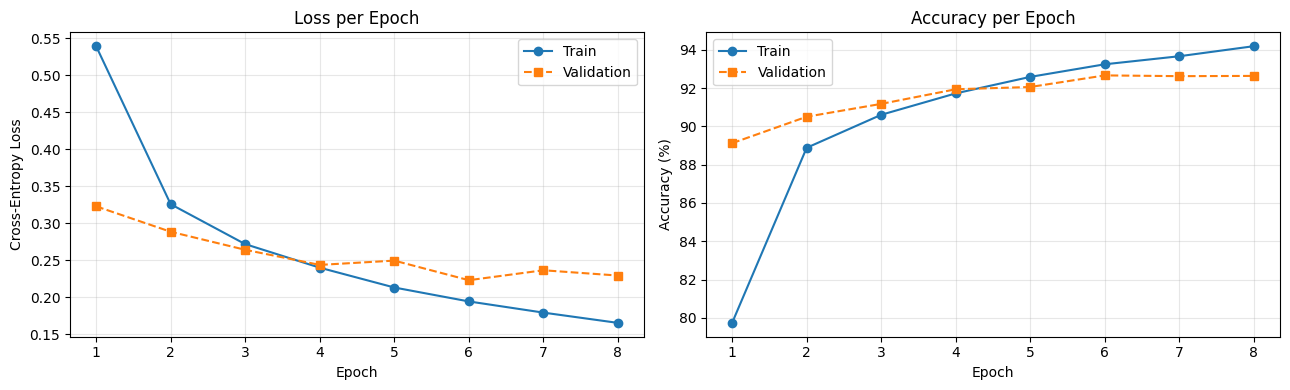

In [12]:
epochs = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history['train_loss'], 'o-', label='Train')
axes[0].plot(epochs, history['val_loss'],   's--', label='Validation')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a * 100 for a in history['train_acc']], 'o-', label='Train')
axes[1].plot(epochs, [a * 100 for a in history['val_acc']],   's--', label='Validation')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

## 8. Evaluation — Classification Report & Confusion Matrix

In [13]:
# Load best checkpoint
model.load_state_dict(torch.load("best_model.pt", map_location=device, weights_only=True))

_, test_acc, preds, labels = evaluate(model, test_loader, criterion)
print(f"Test Accuracy: {test_acc:.2%}
")
print(classification_report(labels, preds, target_names=label_names))

Test Accuracy: 92.66%

              precision    recall  f1-score   support

       World       0.93      0.93      0.93      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.91      0.88      0.90      1900
    Sci/Tech       0.90      0.91      0.90      1900

    accuracy                           0.93      7600
   macro avg       0.93      0.93      0.93      7600
weighted avg       0.93      0.93      0.93      7600



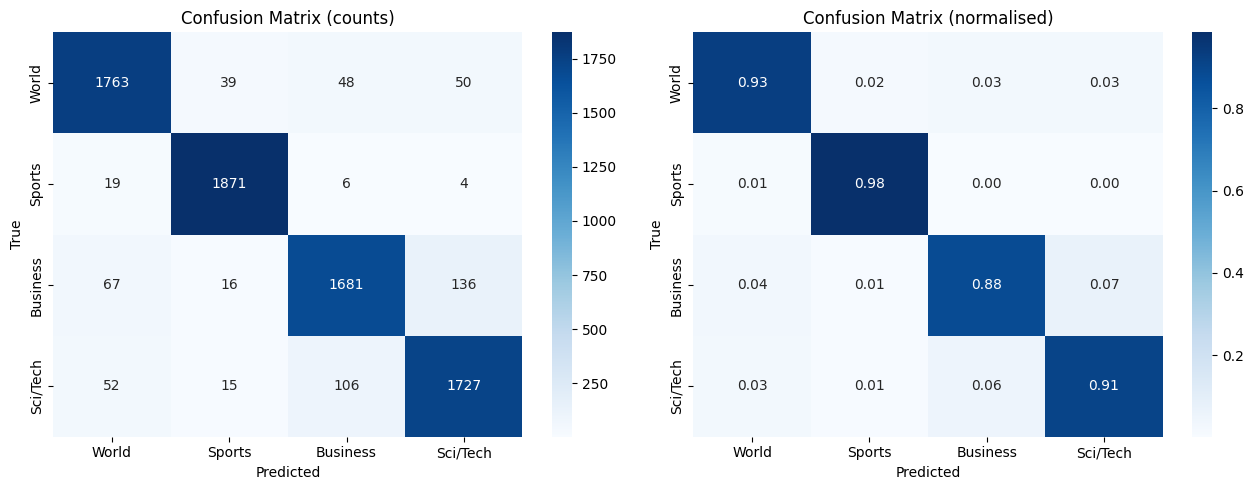

In [14]:
cm = confusion_matrix(labels, preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (normalised)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## 9. Attention Visualisation

We can inspect which words the model focused on for a given document.


True class : World
Text       : Sister of man who died in Vancouver police custody slams chief (Canadian Press) Canadian Press - VANCOUVER (CP) - The sister of a man who died after a violent confrontation with po...


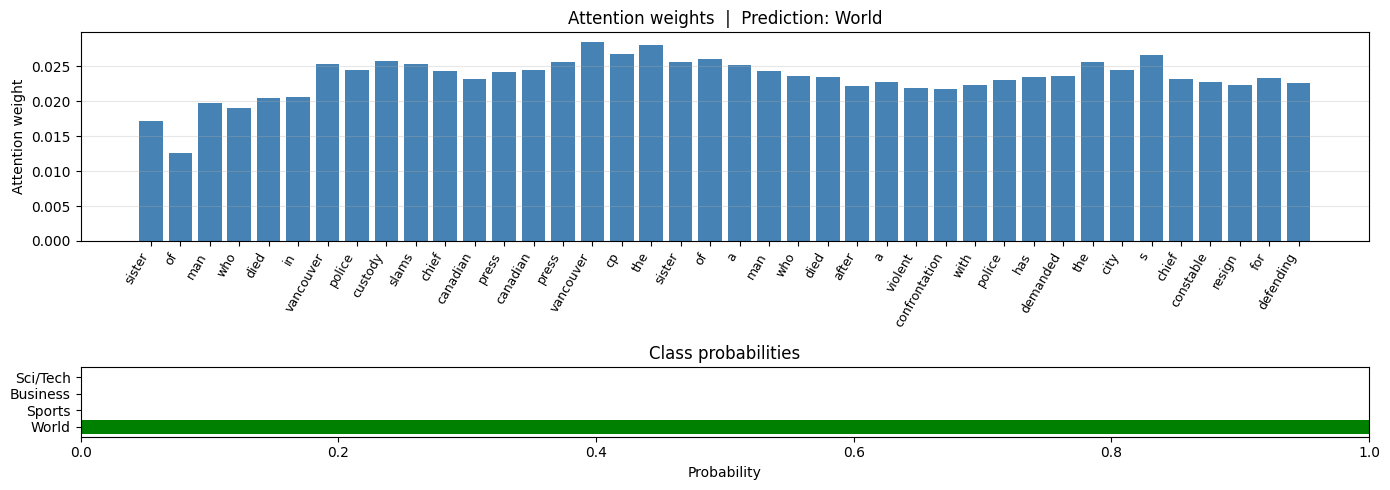

Predicted  : World

True class : Sports
Text       : Giddy Phelps Touches Gold for First Time Michael Phelps won the gold medal in the 400 individual medley and set a world record in a time of 4 minutes 8.26 seconds....


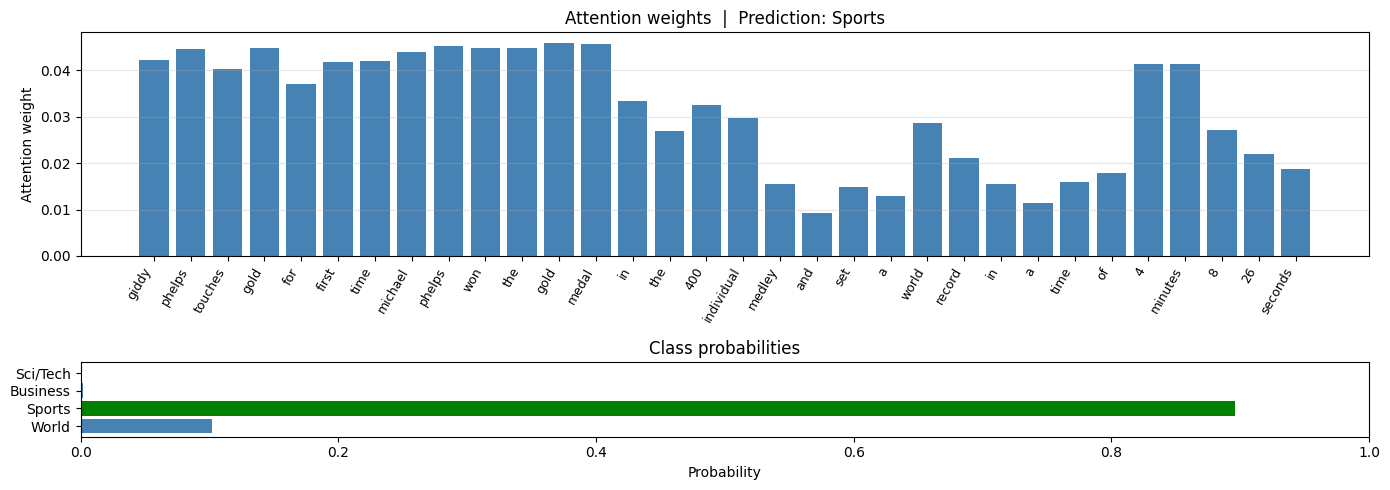

Predicted  : Sports

True class : Business
Text       : Fears for T N pension after talks Unions representing workers at Turner   Newall say they are 'disappointed' after talks with stricken parent firm Federal Mogul....


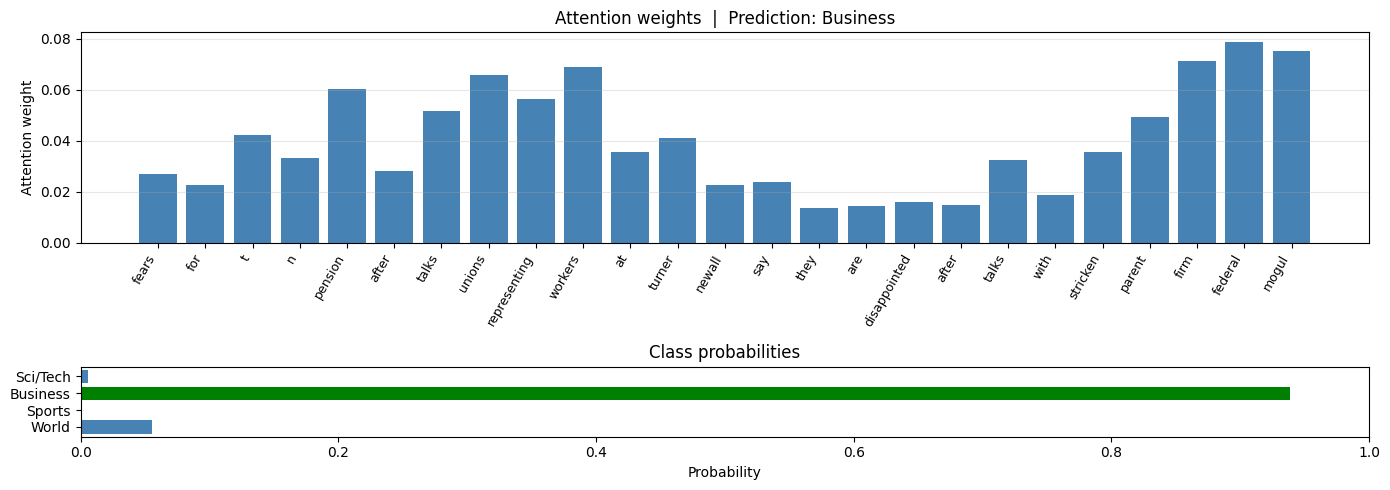

Predicted  : Business

True class : Sci/Tech
Text       : The Race is On: Second Private Team Sets Launch Date for Human Spaceflight (SPACE.com) SPACE.com - TORONTO, Canada -- A second\team of rocketeers competing for the  #36;10 million ...


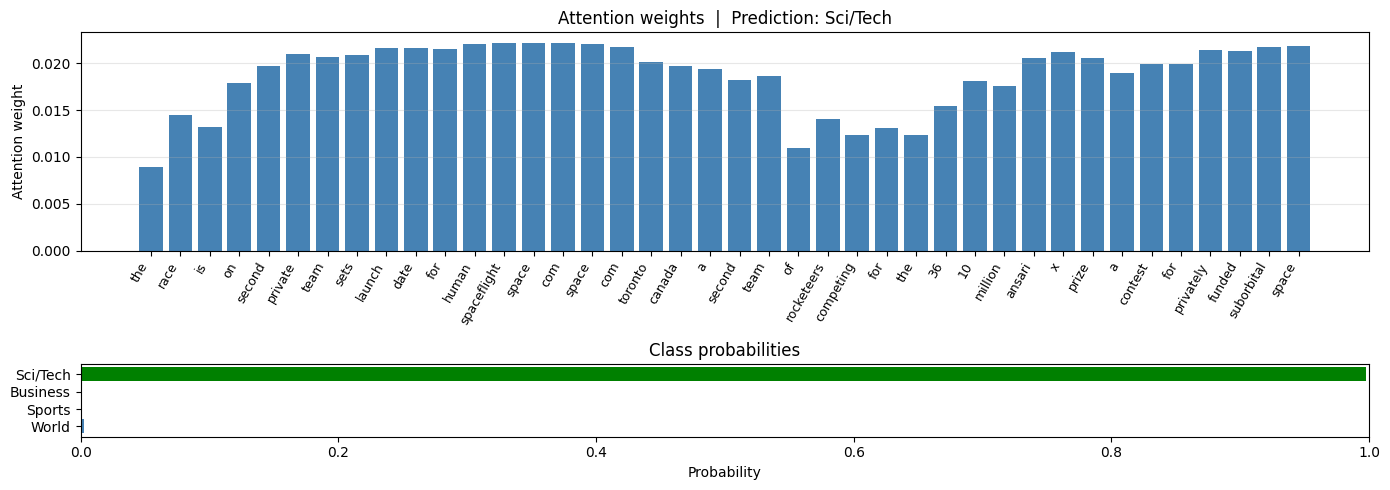

Predicted  : Sci/Tech


In [15]:
@torch.no_grad()
def predict_with_attention(text: str):
    model.eval()
    tokens  = simple_tokenize(text)[:MAX_SEQ_LEN]
    ids     = torch.tensor([encode(text)], dtype=torch.long).to(device)
    logits, attn_weights = model(ids)
    prob    = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    weights = attn_weights.squeeze().cpu().numpy()[:len(tokens)]  # trim PAD
    pred    = label_names[prob.argmax()]
    return tokens, weights, prob, pred


def plot_attention(text: str):
    tokens, weights, probs, pred = predict_with_attention(text)

    # --- bar chart of attention weights ---
    fig, axes = plt.subplots(2, 1, figsize=(14, 5),
                              gridspec_kw={'height_ratios': [3, 1]})

    # Show at most 40 tokens for readability
    n = min(40, len(tokens))
    axes[0].bar(range(n), weights[:n], color='steelblue')
    axes[0].set_xticks(range(n))
    axes[0].set_xticklabels(tokens[:n], rotation=60, ha='right', fontsize=9)
    axes[0].set_ylabel('Attention weight')
    axes[0].set_title(f'Attention weights  |  Prediction: {pred}')
    axes[0].grid(axis='y', alpha=0.3)

    # Class probability bar
    axes[1].barh(label_names, probs, color=['green' if p == probs.max() else 'steelblue' for p in probs])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel('Probability')
    axes[1].set_title('Class probabilities')

    plt.tight_layout()
    plt.savefig('attention_viz.png', dpi=150)
    plt.show()
    return pred


# Pick a real test sample from each class
for cls_idx, cls_name in enumerate(label_names):
    sample = next(s for s in test_data if s['label'] == cls_idx)
    print(f"\n{'='*60}")
    print(f"True class : {cls_name}")
    print(f"Text       : {sample['text'][:180]}...")
    pred = plot_attention(sample['text'])
    print(f"Predicted  : {pred}")

## 10. Attention Heatmap (token × weight)

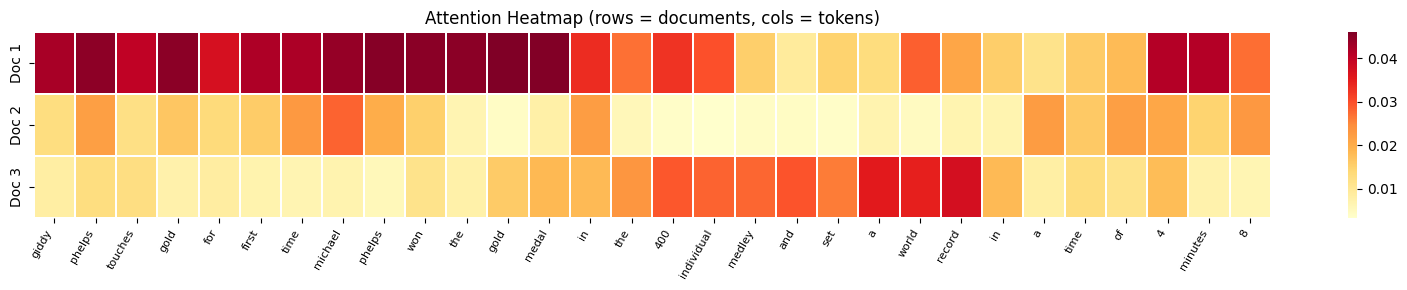

In [16]:
def plot_attention_heatmap(texts: list, max_tokens: int = 30):
    """
    Plot a 2-D heatmap: rows = documents, columns = tokens.
    Useful for comparing attention across multiple samples.
    """
    all_tokens  = []
    all_weights = []

    for text in texts:
        tokens, weights, _, _ = predict_with_attention(text)
        n = min(max_tokens, len(tokens))
        all_tokens.append(tokens[:n])
        all_weights.append(weights[:n])

    # Pad all weight arrays to the same length
    max_len = max(len(w) for w in all_weights)
    padded  = np.zeros((len(all_weights), max_len))
    for i, w in enumerate(all_weights):
        padded[i, :len(w)] = w

    # Use first sample's tokens as column labels (truncated for clarity)
    col_labels = all_tokens[0]
    col_labels += [''] * (max_len - len(col_labels))
    row_labels = [f"Doc {i+1}" for i in range(len(texts))]

    plt.figure(figsize=(16, max(3, len(texts) * 0.8)))
    sns.heatmap(padded, xticklabels=col_labels, yticklabels=row_labels,
                cmap='YlOrRd', linewidths=0.2, annot=False)
    plt.title('Attention Heatmap (rows = documents, cols = tokens)')
    plt.xticks(rotation=60, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()


# Sample 3 test documents from the Sports class
sport_samples = [s['text'] for s in test_data if s['label'] == 1][:3]
plot_attention_heatmap(sport_samples)

## 11. Custom Inference

In [17]:
custom_texts = [
    "NASA launches new Mars rover to study ancient water channels on the red planet surface.",
    "The Fed raised interest rates by 25 basis points amid concerns about persistent inflation.",
    "Manchester United won the Champions League final against Real Madrid on penalties.",
    "Global leaders gather at the UN summit to discuss ceasefire negotiations in the region.",
]

print(f"{'Text':<70}  {'Predicted Class':<12}  Probabilities")
print('-' * 110)

for text in custom_texts:
    tokens, weights, probs, pred = predict_with_attention(text)
    prob_str = '  '.join(f"{label_names[i]}: {p:.2f}" for i, p in enumerate(probs))
    print(f"{text[:68]:<70}  {pred:<14}  {prob_str}")

Text                                                                    Predicted Class  Probabilities
--------------------------------------------------------------------------------------------------------------
NASA launches new Mars rover to study ancient water channels on the     Sci/Tech        World: 0.00  Sports: 0.00  Business: 0.00  Sci/Tech: 1.00
The Fed raised interest rates by 25 basis points amid concerns about    Business        World: 0.01  Sports: 0.00  Business: 0.99  Sci/Tech: 0.00
Manchester United won the Champions League final against Real Madrid    Sports          World: 0.02  Sports: 0.98  Business: 0.00  Sci/Tech: 0.00
Global leaders gather at the UN summit to discuss ceasefire negotiat    World           World: 1.00  Sports: 0.00  Business: 0.00  Sci/Tech: 0.00


In [18]:
import os

save_path = "attention_lstm_agnews.pt"

checkpoint = {
    "model_state_dict": model.state_dict(),
    "word2idx"        : word2idx,
    "idx2word"        : idx2word,
    "label_names"     : label_names,
    "model_config": {
        "vocab_size" : VOCAB_SIZE,
        "embed_dim"  : EMBED_DIM,
        "hidden_dim" : HIDDEN_DIM,
        "n_layers"   : N_LAYERS,
        "n_classes"  : N_CLASSES,
        "dropout"    : DROPOUT,
        "max_seq_len": MAX_SEQ_LEN,
    },
}

torch.save(checkpoint, save_path)
print(f"Checkpoint saved -> {os.path.abspath(save_path)}")
print(f"  vocab size  : {len(word2idx):,}")
print(f"  label names : {label_names}")
print(f"  file size   : {os.path.getsize(save_path)/1e6:.1f} MB")

Model checkpoint saved to: /content/attention_lstm_agnews.pt


In [19]:
import os, re

ckpt_path = "attention_lstm_agnews.pt"
assert os.path.exists(ckpt_path), f"Checkpoint not found: {os.path.abspath(ckpt_path)}"

checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
cfg               = checkpoint["model_config"]
loaded_word2idx   = checkpoint["word2idx"]
loaded_label_names = checkpoint["label_names"]

# Rebuild model from saved config
loaded_model = AttentionLSTM(
    vocab_size=cfg["vocab_size"],
    embed_dim =cfg["embed_dim"],
    hidden_dim=cfg["hidden_dim"],
    n_layers  =cfg["n_layers"],
    n_classes =cfg["n_classes"],
    dropout   =cfg["dropout"],
).to(device)
loaded_model.load_state_dict(checkpoint["model_state_dict"])
loaded_model.eval()
print("Model loaded successfully.")

# IMPORTANT: tokenizer must exactly match the one used during training
def encode_loaded(text, max_len=cfg["max_seq_len"]):
    tokens = re.findall(r"[a-z0-9]+", text.lower())[:max_len]
    ids    = [loaded_word2idx.get(t, 1) for t in tokens]
    ids   += [0] * (max_len - len(ids))
    return ids

test_sentences = [
    "Apple reports record quarterly profits as iPhone sales rise globally.",
    "Scientists discover new exoplanet in the habitable zone of a nearby star.",
    "Manchester City wins the Premier League title for the fourth time.",
    "UN Security Council votes on new sanctions against North Korea.",
]

print(f"
{chr(39)}Text{chr(39):<65}  Predicted      Confidence")
print("-" * 90)
for text in test_sentences:
    ids    = torch.tensor([encode_loaded(text)], dtype=torch.long).to(device)
    with torch.no_grad():
        logits, _ = loaded_model(ids)
        probs     = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred  = loaded_label_names[int(probs.argmax())]
    conf  = float(probs.max())
    print(f"{text[:63]:<65}  {pred:<14} {conf:.1%}")


Loaded checkpoint: /content/attention_lstm_agnews.pt
Sample prediction: Sci/Tech
Probabilities: {'World': 0.0030152148101478815, 'Sports': 1.1973833352385554e-05, 'Business': 0.44139888882637024, 'Sci/Tech': 0.5555739402770996}


## 12. Summary

| Component | Details |
|---|---|
| Dataset | AG News (4-class, 120k train / 7.6k test) |
| Embedding | Learned from scratch — 128-d |
| Encoder | Bidirectional 2-layer LSTM, 256 hidden per direction |
| Attention | Bahdanau additive attention (single head) |
| Classifier | Linear layer → 4-way softmax |
| Regularisation | Dropout (0.4) + gradient clipping (max-norm 1.0) |
| Optimiser | Adam + ReduceLROnPlateau |
| Expected accuracy | ~91–92% on test set |

### Why Attention + LSTM?
- A plain LSTM compresses the entire sequence into a single final hidden state — long documents cause the model to "forget" early content.
- Attention lets the model **look back** at every position and weight them dynamically, focusing on the most informative words regardless of their position.
- The weight vectors (visualised above) give interpretability: you can inspect exactly which words drove each prediction.